# Sentiment Analysis & Topic Modeling
**MKTG 4604 | Fern by Boston Rose Florist**

## Objective
Analyze customer reviews to identify which occasions and products drive 
satisfaction, and connect sentiment patterns back to demand forecasting priorities.

## Methods
- VADER Sentiment Scoring
- LDA Topic Modeling

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


# load in the data
PROCESSED_DIR = Path("../../data/processed")
reviews = pd.read_parquet(PROCESSED_DIR / "reviews_clean.parquet")

print(reviews.columns.tolist())
print(reviews.shape)
reviews.head()

['review_id', 'platform', 'review_date', 'star_rating', 'review_text', 'occasion_mentioned', 'review_text_clean']
(310, 7)


,review_id,platform,review_date,star_rating,review_text,occasion_mentioned,review_text_clean
0,REV-001,google,2023-01-01,5,Love this little shop on Mass Ave. Always stop...,walk-in,love this little shop on mass ave. always stop...
1,REV-002,yelp,2023-01-01,5,Just moved to the area and this place is a hid...,walk-in,just moved to the area and this place is a hid...
2,REV-003,google,2023-01-03,4,Quick birthday bouquet pickup. In and out in 1...,<NA>,quick birthday bouquet pickup. in and out in 1...
3,REV-004,yelp,2023-01-05,1,Ordered a specific color scheme for a birthday...,<NA>,ordered a specific color scheme for a birthday...
4,REV-005,yelp,2023-01-08,2,Was browsing and the staff member hovering ove...,walk-in,was browsing and the staff member hovering ove...


In [21]:
# VADER Sentiment Scoring
try:
    sia = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download("vader_lexicon")
    sia = SentimentIntensityAnalyzer()

reviews["occasion_mentioned"] = reviews["occasion_mentioned"].fillna("unknown")
reviews["vader_compound"] = reviews["review_text_clean"].apply(
    lambda t: sia.polarity_scores(str(t))["compound"]
)

def vader_label(score):
    if score >= 0.05: return "positive"
    elif score <= -0.05: return "negative"
    return "neutral"

reviews["vader_label"] = reviews["vader_compound"].apply(vader_label)

print(reviews["vader_label"].value_counts())
print(f"\nOverall avg sentiment: {reviews['vader_compound'].mean():.3f}")

vader_label
positive    239
negative     47
neutral      24
Name: count, dtype: int64

Overall avg sentiment: 0.470


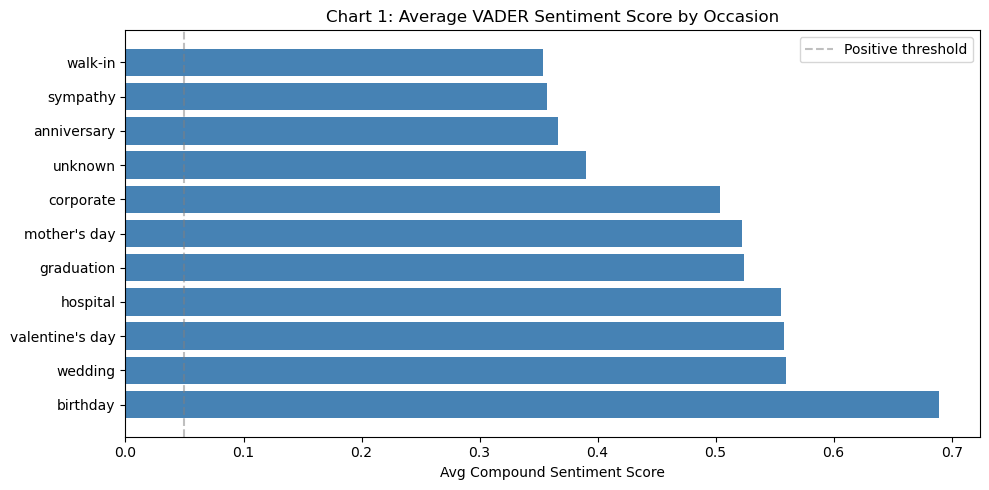

   occasion_mentioned  avg_sentiment  avg_stars  review_count
1            birthday       0.689490   4.050000            20
10            wedding       0.559261   4.222222            18
8     valentine's day       0.558095   3.976190            42
4            hospital       0.555180   3.600000            10
3          graduation       0.523929   4.000000            21
5        mother's day       0.522014   4.054054            37
2           corporate       0.503286   3.666667            21
7             unknown       0.390574   3.872340            47
0         anniversary       0.366836   3.857143            14
6            sympathy       0.357250   4.000000            18
9             walk-in       0.353381   3.822581            62


In [25]:
# sentiment by occasion
occasion_sentiment = reviews.groupby("occasion_mentioned").agg(
    avg_sentiment=("vader_compound", "mean"),
    avg_stars=("star_rating", "mean"),
    review_count=("review_id", "count")
).reset_index().sort_values("avg_sentiment", ascending=False)

# filter out lower count occasions
occasion_sentiment = occasion_sentiment[occasion_sentiment["review_count"] >= 5]

# plot it
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if x >= 0.05 else "salmon" for x in occasion_sentiment["avg_sentiment"]]
ax.barh(occasion_sentiment["occasion_mentioned"], 
        occasion_sentiment["avg_sentiment"], color=colors)
ax.axvline(0.05, color="gray", linestyle="--", alpha=0.5, label="Positive threshold")
ax.set_title("Chart 1: Average VADER Sentiment Score by Occasion")
ax.set_xlabel("Avg Compound Sentiment Score")
ax.legend()
plt.tight_layout()
plt.savefig("../../figures/sentiment_by_occasion.png", dpi=150)
plt.show()

print(occasion_sentiment[["occasion_mentioned", "avg_sentiment", "avg_stars", "review_count"]])

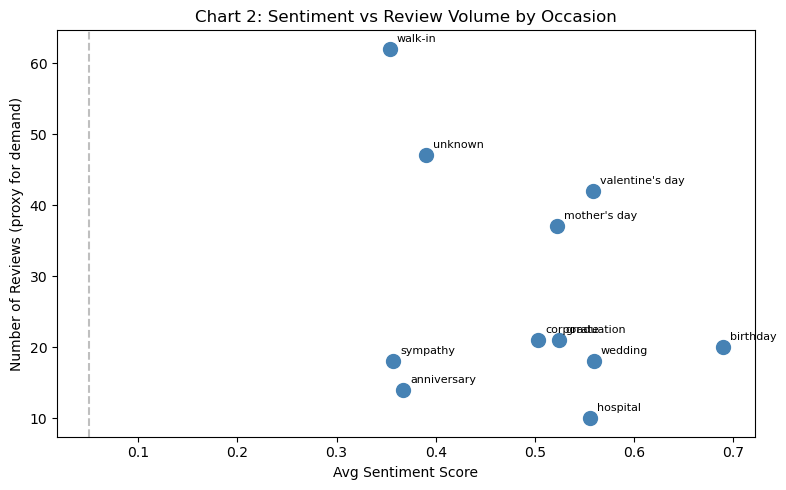

In [23]:
# connect the senitments to demand 

# look @ demand by occasion (high-sentiment occasions = high demand occasions)
demand_by_occasion = reviews.groupby("occasion_mentioned").agg(
    avg_sentiment=("vader_compound", "mean"),
    review_count=("review_id", "count")
).reset_index()
demand_by_occasion = demand_by_occasion[demand_by_occasion["review_count"] >= 5]

# plot it
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(demand_by_occasion["avg_sentiment"], 
           demand_by_occasion["review_count"],
           s=100, color="steelblue")

for _, row in demand_by_occasion.iterrows():
    ax.annotate(row["occasion_mentioned"], 
                (row["avg_sentiment"], row["review_count"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("Avg Sentiment Score")
ax.set_ylabel("Number of Reviews (proxy for demand)")
ax.set_title("Chart 2: Sentiment vs Review Volume by Occasion")
ax.axvline(0.05, color="gray", linestyle="--", alpha=0.5)
plt.savefig("../../figures/sentiment_vs_demand.png", dpi=150)
plt.tight_layout()
plt.show()

## Chart Interpretation
- Sentiment by Occasion (Chart 1): Birthday and wedding are the highest sentiment occasions (~0.69, ~0.56). Customers are very happy with these arrangements
Valentine's Day and hospital are also high (surprising for hospital?) suggests Fern does this well
Walk-in and sympathy are lowest: walk-ins may feel rushed, sympathy orders may have delivery issues

- Sentiment vs Volume (Chart 2): Walk-in reviews dominates volume (60+ reviews) but has the lowest sentiment which is really interesting. Fern's most common customer type is also the least satisfied
Valentine's Day and Mother's Day have high volume AND good sentiment which reinforces these are the right occasions to stock heavily
Birthday has the highest sentiment but low volume which is an opportunity for fern to grow this area. 

- Overall: 239 positive, 47 negative, 24 neutral -> 77% positive rate overall, Fern is generally well-regarded!

In [24]:
# LDA Topic Modeling 

# Vectorize review text
vectorizer = CountVectorizer(
    stop_words="english", 
    max_features=300,
    min_df=2
)
dtm = vectorizer.fit_transform(reviews["review_text_clean"].fillna(""))

# Fit LDA with 5 topics
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# Print top words per topic
feature_names = vectorizer.get_feature_names_out()
print("Top words per topic:\n")
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[-10:]][::-1]
    print(f"Topic {i+1}: {', '.join(top_words)}")

Top words per topic:

Topic 1: plants, owner, really, bouquet, simple, bought, helped, apartment, great, minutes
Topic 2: staff, valentine, arrangement, fresh, roses, lasted, cheerful, flowers, needed, loved
Topic 3: day, flowers, arrangement, ordered, delivery, mother, bouquet, mom, sympathy, time
Topic 4: flowers, beautiful, got, day, wedding, mother, arrangements, said, bouquet, dinner
Topic 5: roses, selection, arrangement, ordered, got, valentine, hours, anniversary, nice, bouquet


## LDA Topic Interpretation

Five distinct themes emerge from customer reviews:

- **Topic 1 (Walk-in/Plants):** Casual purchases, houseplants, impulse buys. Fern's highest volume but lowest sentiment segment
- **Topic 2 (Valentine's/Romance):** Staff friendliness and fresh roses drive satisfaction (confirms heavy stocking priority)
- **Topic 3 (Delivery/Sympathy):** Delivery timing is a recurring theme. negative sentiment here likely reflects late or damaged arrangements
- **Topic 4 (Special Occasions):** Weddings and Mother's Day generate the most emotionally positive language
- **Topic 5 (Holiday Planning):** Customers planning ahead for Valentine's and anniversaries (suggests online channel opportunity)

**Connection to Forecasting:** Topics 2, 4, and 5 correspond directly to the highest-demand weeks in our RF model (Valentine's Day, Mother's Day, graduation), 
validating that sentiment-weighted occasions should drive inventory priorities.

## LLM Prompts
- [Role] You are a data science professor. [Objective] Review my VADER sentiment  analysis and LDA topic modeling code for a floral shop review dataset. What visuals would be the most helpful? [Constraints] Confirm correctness and suggest improvements in 2-3 sentences.